# A2: Exploratory Visual Analysis – Visualizations

**Subtheme:** Transit / Transit-Oriented Development

Setup:
1. From the `A2` folder: `python3 -m venv venv`
2. Activate: `source venv/bin/activate` (Mac/Linux) or `venv\Scripts\activate` (Windows)
3. Install: `pip install -r requirements.txt`
4. Run Jupyter: `jupyter notebook` or open this file in VS Code / Cursor

## Setup
Run the cells below once (imports, paths, load data, join sales to nearest stop). You can collapse this section in the outline after running.

In [91]:
import json
import numpy as np
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.family"] = "sans-serif"
sns.set_theme(style="whitegrid", palette="muted")

In [92]:
# Paths – run from A2 folder so that Path.cwd() is A2
DATA_DIR = Path.cwd() / "A2 datasets [SHARED]"
MBTA_DIR = DATA_DIR / "MBTA Network"
SALES_PATH = DATA_DIR / "Residential sales data in the City of Boston, 2000-2023" / "A2_EDA_Residential.csv"
ZONING_CSV = DATA_DIR / "Single family zoning vs other housing zoning in Metro Boston" / "housing_sf_other_w_census.csv"

assert DATA_DIR.exists(), f"Data dir not found: {DATA_DIR}. Run this notebook from the A2 folder."

In [93]:
# Load MBTA stops (point file for lat/lon coords + route info)
stops_path = MBTA_DIR / "mbta_stops" / "mbta_stops_collapsed.geojson"
with open(stops_path) as f:
    stops_geojson = json.load(f)

def classify_mode(zone_id):
    """Coarse transit mode from zone_id field."""
    if zone_id == "RapidTransit":
        return "Rapid Transit"
    elif zone_id.startswith("CR-zone"):
        return "Commuter Rail"
    elif zone_id.startswith("Boat"):
        return "Ferry"
    else:
        return "Bus"

def cr_zone_num(zone_id):
    """Extract commuter rail zone number (1-10) from zone_id, e.g. CR-zone-3 -> 3."""
    if zone_id.startswith("CR-zone-"):
        suffix = zone_id.replace("CR-zone-", "")
        try:
            return int(suffix)
        except ValueError:
            return None  # e.g. CR-zone-1A
    return None

def flatten_stop(feature):
    p = feature.get("properties", {})
    routes = p.get("routes", [])
    n_routes = len(routes)
    route_type = routes[0].get("route_type") if routes else None
    route_desc = routes[0].get("route_desc", "") if routes else ""
    zone_id = p.get("zone_id", "")
    coords = feature["geometry"]["coordinates"]  # GeoJSON: [lon, lat]
    return {
        "stop_id": p.get("stop_id"),
        "stop_name": p.get("stop_name"),
        "zone_id": zone_id,
        "mode": classify_mode(zone_id),
        "cr_zone": cr_zone_num(zone_id),
        "n_routes": n_routes,
        "route_type": route_type,
        "route_desc": route_desc,
        "is_hub": n_routes >= 2,
        "lat": coords[1],
        "lon": coords[0],
    }

stops = pd.DataFrame([flatten_stop(f) for f in stops_geojson["features"]])
print(stops.shape)
print(stops["mode"].value_counts())
stops.head()

(7087, 11)
mode
Bus              6812
Commuter Rail     138
Rapid Transit     125
Ferry              12
Name: count, dtype: int64


,stop_id,stop_name,zone_id,mode,cr_zone,n_routes,route_type,route_desc,is_hub,lat,lon
0,8328,1 W Milton St opp Ernest Ave,LocalBus,Bus,NaN,1,3,Local Bus,False,42.240706,-71.143445
1,14586,10 Centennial Drive - Boston Children's @ Peabody,LocalBus,Bus,NaN,1,3,Local Bus,False,42.526045,-70.951632
2,24586,10 Centennial Drive - West,LocalBus,Bus,NaN,1,3,Local Bus,False,42.526993,-70.954649
3,49798,10 Oak Park Dr,LocalBus,Bus,NaN,1,3,Commuter Bus,False,42.515416,-71.250401
4,4561,10 Sylvan St,LocalBus,Bus,NaN,2,3,Local Bus,True,42.546524,-70.945447


In [94]:
# Load residential sales (Boston) and housing zoning
sales = pd.read_csv(SALES_PATH)
sales["date"] = pd.to_datetime(sales["date"], errors="coerce")
print("Sales:", sales.shape)
print("Styles:", sales["style"].value_counts().head(15).to_string())

zoning = pd.read_csv(ZONING_CSV)
print("\nZoning:", zoning.shape)

Sales: (49301, 63)
Styles: style
ROW-MIDDLE      17788
MID-RISE        12311
HIGH-RISE        7632
ROW-END          5292
LOW-RISE         2144
CONDO/APT         891
FREE-STANDNG      452
SEMI DETACHD       62
RAISED CAPE        60
TOWNHOUSE          46
DECKER             46
CONVENTIONAL       15
COLONIAL            7
DUPLEX              4
CONTEMPORARY        1

Zoning: (153, 53)


In [95]:
# --- Data prep: join each sale to its nearest MBTA stop by lat/lon distance ---

# Drop sales without valid coordinates or price.
# Two geocoding-failure patterns exist in this dataset:
#   1) lat=0 / lon=0  (456 properties – null-island fallback)
#   2) lat≈42.66, lon≈-70.63  (157 properties – Rockport, MA fallback)
# Both groups are filtered by requiring coordinates inside Boston city bounds.
BOSTON_LAT = (42.20, 42.45)
BOSTON_LON = (-71.25, -70.95)
sales_clean = sales.dropna(subset=["lat", "lon", "price"]).copy()
sales_clean = sales_clean[
    (sales_clean["price"] > 0) &
    (sales_clean["lat"].between(*BOSTON_LAT)) &
    (sales_clean["lon"].between(*BOSTON_LON))
].reset_index(drop=True)

# Simplify housing style into fewer readable categories
style_map = {
    "HIGH-RISE":       "High-Rise",
    "MID-RISE":        "Mid-Rise",
    "LOW-RISE":        "Low-Rise",
    "ROW-MIDDLE":      "Rowhouse",
    "ROW-CORNER":      "Rowhouse",
    "ROW-END":         "Rowhouse",
    "CONDO/APT":       "Condo/Apt",
    "FREE-STANDNG":    "Single Family",
    "SEMI DETACHD":    "Semi-Detached",
    "DECKER":          "Multi-Unit",
    "TOWNHOUSE":       "Rowhouse",
}
sales_clean["style_simple"] = sales_clean["style"].map(style_map).fillna("Other")

# Assign each sale to the mode of its nearest MBTA stop (with tie-breaker).
# Note: after filtering bad geocodes, only ~4 Boston properties have a CR stop
# as their nearest stop, so CR is effectively unused for visualizations.
stops_rt   = stops[stops["mode"] == "Rapid Transit"]
stops_cr   = stops[stops["mode"] == "Commuter Rail"]
stops_bus  = stops[stops["mode"] == "Bus"]
coords_rt  = stops_rt[["lat", "lon"]].values
coords_cr  = stops_cr[["lat", "lon"]].values
coords_bus = stops_bus[["lat", "lon"]].values
sale_coords = sales_clean[["lat", "lon"]].values
n_sales = len(sale_coords)
BATCH = 2000

dist_rt_min  = np.empty(n_sales)
dist_cr_min  = np.empty(n_sales)
dist_bus_min = np.empty(n_sales)
nearest_rt_ix  = np.empty(n_sales, dtype=int)
nearest_cr_ix  = np.empty(n_sales, dtype=int)
nearest_bus_ix = np.empty(n_sales, dtype=int)

for i in range(0, n_sales, BATCH):
    batch = sale_coords[i:i+BATCH]
    d_rt  = np.sqrt((batch[:, 0:1] - coords_rt[:, 0]) ** 2 + (batch[:, 1:2] - coords_rt[:, 1]) ** 2)
    d_cr  = np.sqrt((batch[:, 0:1] - coords_cr[:, 0]) ** 2 + (batch[:, 1:2] - coords_cr[:, 1]) ** 2)
    d_bus = np.sqrt((batch[:, 0:1] - coords_bus[:, 0]) ** 2 + (batch[:, 1:2] - coords_bus[:, 1]) ** 2)
    dist_rt_min[i:i+BATCH]  = d_rt.min(axis=1)
    dist_cr_min[i:i+BATCH]  = d_cr.min(axis=1)
    dist_bus_min[i:i+BATCH] = d_bus.min(axis=1)
    nearest_rt_ix[i:i+BATCH]  = d_rt.argmin(axis=1)
    nearest_cr_ix[i:i+BATCH]  = d_cr.argmin(axis=1)
    nearest_bus_ix[i:i+BATCH] = d_bus.argmin(axis=1)

# Tie-breaker: prefer Rapid Transit > Commuter Rail > Bus (so urban areas near both RT and CR count as RT)
mode = np.where(
    (dist_rt_min <= dist_cr_min) & (dist_rt_min <= dist_bus_min), "Rapid Transit",
    np.where(dist_cr_min <= dist_bus_min, "Commuter Rail", "Bus")
)
# Global stop index for the chosen mode (for is_hub, n_routes, cr_zone)
chosen_rt  = stops_rt.index[nearest_rt_ix]
chosen_cr  = stops_cr.index[nearest_cr_ix]
chosen_bus = stops_bus.index[nearest_bus_ix]
chosen_ix  = np.where(mode == "Rapid Transit", chosen_rt, np.where(mode == "Commuter Rail", chosen_cr, chosen_bus))
nearest_stops = stops.loc[chosen_ix].reset_index(drop=True)

sales_clean["transit_mode"]     = mode
sales_clean["nearest_stop_id"]  = nearest_stops["stop_id"].values
sales_clean["is_hub"]           = nearest_stops["is_hub"].values
sales_clean["n_routes_nearby"]  = nearest_stops["n_routes"].values
sales_clean["cr_zone"]          = nearest_stops["cr_zone"].values

print("Sales joined:", sales_clean.shape)
print(sales_clean["transit_mode"].value_counts())
print(sales_clean["style_simple"].value_counts())

Sales joined: (48686, 69)
transit_mode
Bus              41727
Rapid Transit     6955
Commuter Rail        4
Name: count, dtype: int64
style_simple
Rowhouse         22960
Mid-Rise         12032
High-Rise         7533
Other             2592
Low-Rise          2124
Condo/Apt          889
Single Family      449
Semi-Detached       61
Multi-Unit          46
Name: count, dtype: int64


## Q1: Do different transit types have different housing surrounding them?

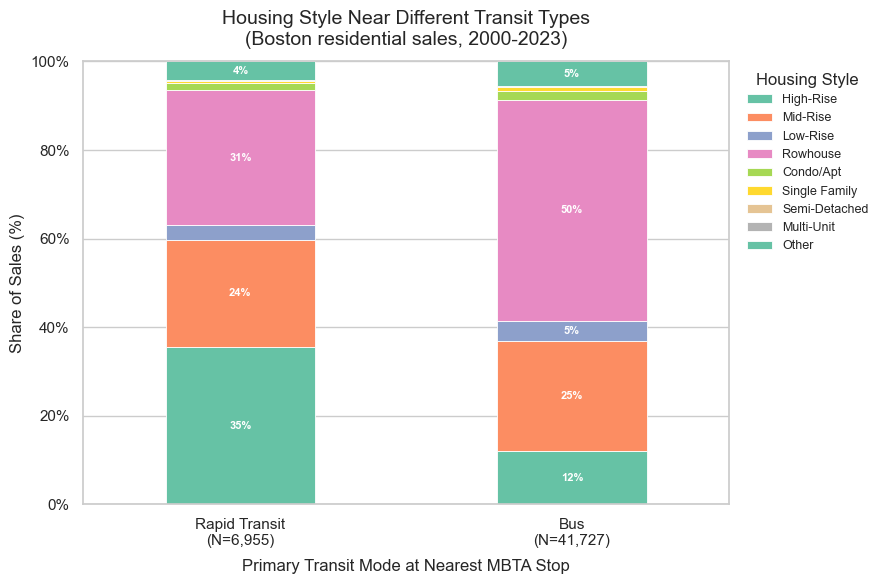

In [96]:
# Q1 Chart: Housing style distribution by transit mode
# Each bar = one transit mode; segments = share of each housing style.
# Commuter Rail is excluded: after removing geocoding-error rows, only 4 Boston
# properties genuinely have a CR stop as their nearest MBTA stop – too few to plot.

if "sales_clean" not in dir():
    raise RuntimeError("Run the 'Data prep' cell above first (join sales to nearest stop).")

MODES   = ["Rapid Transit", "Bus"]
STYLES  = ["High-Rise", "Mid-Rise", "Low-Rise", "Rowhouse", "Condo/Apt", "Single Family", "Semi-Detached", "Multi-Unit", "Other"]
COLORS  = sns.color_palette("Set2", n_colors=len(STYLES))

subset = sales_clean[sales_clean["transit_mode"].isin(MODES)].copy()
mode_counts = subset["transit_mode"].value_counts()
ct = (
    pd.crosstab(subset["transit_mode"], subset["style_simple"], normalize="index") * 100
).reindex(index=MODES).reindex(columns=STYLES, fill_value=0)

fig, ax = plt.subplots(figsize=(9, 6))
ct.plot(kind="bar", stacked=True, ax=ax, color=COLORS, edgecolor="white", linewidth=0.6, width=0.45)

ax.set_title("Housing Style Near Different Transit Types\n(Boston residential sales, 2000-2023)", fontsize=14, pad=12)
ax.set_xlabel("Primary Transit Mode at Nearest MBTA Stop", labelpad=8)
ax.set_ylabel("Share of Sales (%)")
ax.set_xticklabels(
    [f"{m}\n(N={mode_counts[m]:,})" for m in MODES],
    rotation=0, fontsize=11
)
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title="Housing Style", bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, fontsize=9)

# Annotate each segment with its % if large enough
for i, mode in enumerate(MODES):
    cum = 0
    for j, style in enumerate(STYLES):
        val = ct.loc[mode, style]
        if val > 4:
            ax.text(i, cum + val / 2, f"{val:.0f}%", ha="center", va="center", fontsize=8, color="white", fontweight="bold")
        cum += val

plt.tight_layout()
plt.savefig("q1-housing-by-mode.png", dpi=150, bbox_inches="tight")
plt.show()

## Q2: How does transit access relate to housing affordability?

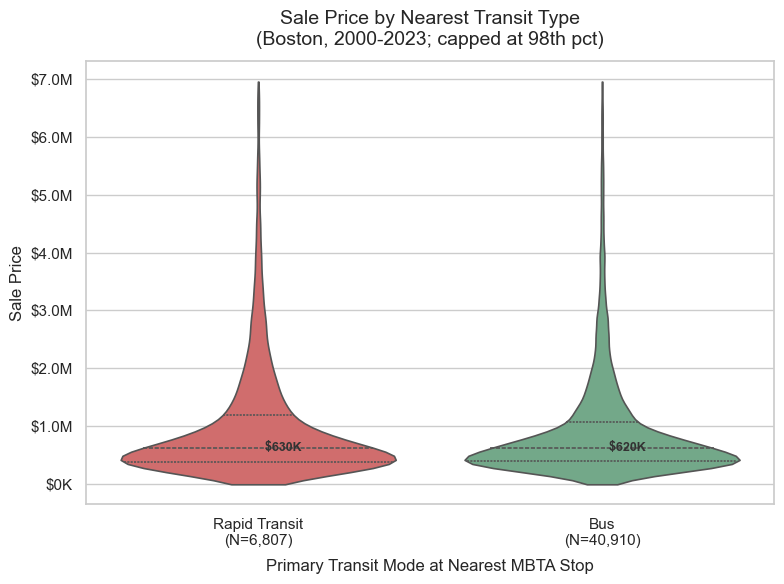

In [97]:
# Q2 Chart 1: Sale price distribution by transit mode (violin + quartile box)
# Commuter Rail excluded – after geocoding-error filtering only 4 valid CR-mode properties remain.
if "sales_clean" not in dir():
    raise RuntimeError("Run the 'Data prep' cell above first.")

MODES = ["Rapid Transit", "Bus"]
PALETTE = {"Rapid Transit": "#e05c5c", "Bus": "#6ab187"}

# Cap at 98th percentile so outliers don't crush the chart
cap = sales_clean["price"].quantile(0.98)
subset = sales_clean[sales_clean["transit_mode"].isin(MODES) & (sales_clean["price"] <= cap)].copy()
mode_counts = subset["transit_mode"].value_counts()

# Median lines for annotation
medians = subset.groupby("transit_mode")["price"].median()

fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(
    data=subset, x="transit_mode", y="price", order=MODES,
    hue="transit_mode", palette=PALETTE, legend=False,
    inner="quartile", linewidth=1.2, cut=0, ax=ax
)

# Annotate medians
for i, mode in enumerate(MODES):
    med = medians[mode]
    ax.text(i, med, f"  ${med/1e3:.0f}K", va="center", fontsize=9, fontweight="bold", color="#333")

ax.set_title("Sale Price by Nearest Transit Type\n(Boston, 2000-2023; capped at 98th pct)", fontsize=14, pad=12)
ax.set_xlabel("Primary Transit Mode at Nearest MBTA Stop", labelpad=8)
ax.set_ylabel("Sale Price")
ax.set_xticks(range(len(MODES)))
ax.set_xticklabels(
    [f"{m}\n(N={mode_counts[m]:,})" for m in MODES],
    fontsize=11
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x/1e3:.0f}K"))

plt.tight_layout()
plt.savefig("q2-price-by-mode.png", dpi=150, bbox_inches="tight")
plt.show()

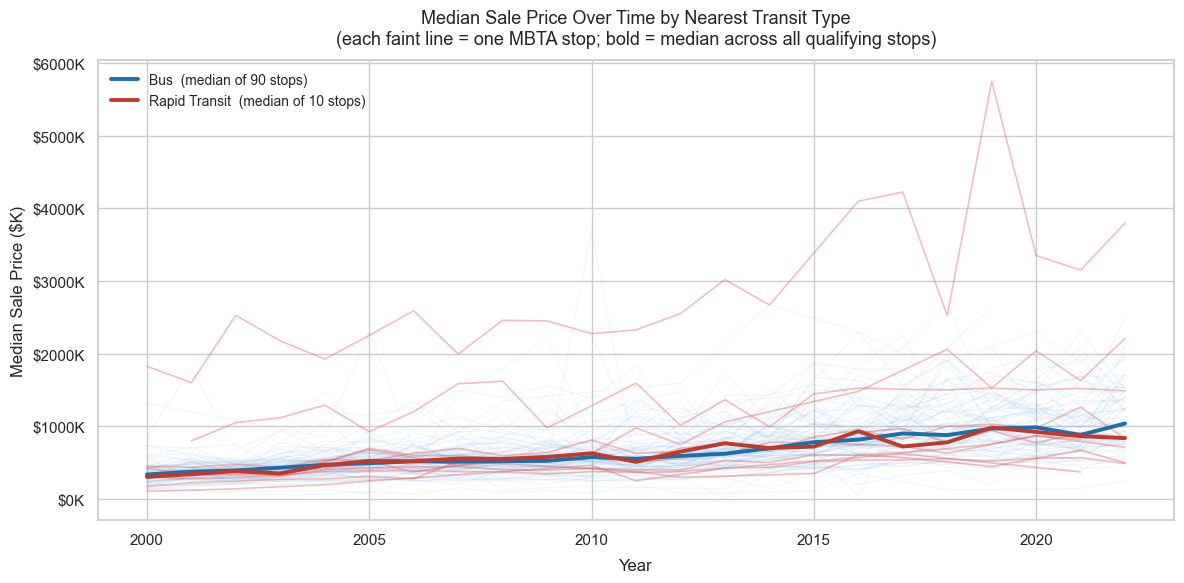

In [98]:
# Q2 Chart 2: Median sale price over time — one line per MBTA stop
# Blue faint lines  = individual bus stops
# Red  faint lines  = individual rapid-transit stops
# Bold lines = median-of-medians across all qualifying stops of each type
# Only stops with >= MIN_PER_YEAR sales in a given year AND >= MIN_YEARS such years are shown.
if "sales_clean" not in dir():
    raise RuntimeError("Run the 'Data prep' cell above first.")

sales_clean["year"] = pd.to_datetime(sales_clean["date"], errors="coerce").dt.year

MIN_PER_YEAR = 5   # min sales at a stop in a given year
MIN_YEARS    = 10  # stop must have this many qualifying years

cap_price = sales_clean["price"].quantile(0.98)
subset = sales_clean[
    sales_clean["transit_mode"].isin(["Rapid Transit", "Bus"]) &
    (sales_clean["price"] <= cap_price)
].dropna(subset=["year"]).copy()

by_sy = (
    subset
    .groupby(["nearest_stop_id", "year", "transit_mode"], as_index=False)["price"]
    .agg(median="median", n="count")
)
by_sy = by_sy[by_sy["n"] >= MIN_PER_YEAR]

yr_counts = by_sy.groupby("nearest_stop_id")["year"].count()
keep = yr_counts[yr_counts >= MIN_YEARS].index
by_sy = by_sy[by_sy["nearest_stop_id"].isin(keep)]

rt_stops  = by_sy[by_sy["transit_mode"] == "Rapid Transit"]["nearest_stop_id"].unique()
bus_stops = by_sy[by_sy["transit_mode"] == "Bus"]["nearest_stop_id"].unique()

fig, ax = plt.subplots(figsize=(12, 6))

# Faint per-stop lines
for sid in bus_stops:
    d = by_sy[by_sy["nearest_stop_id"] == sid].sort_values("year")
    ax.plot(d["year"], d["median"] / 1e3, color="#4a90d9", alpha=0.07, linewidth=0.9)

for sid in rt_stops:
    d = by_sy[by_sy["nearest_stop_id"] == sid].sort_values("year")
    ax.plot(d["year"], d["median"] / 1e3, color="#e05c5c", alpha=0.40, linewidth=1.2)

# Bold per-mode median-of-medians
for mode, color, lbl in [
    ("Bus",           "#1a6fad", f"Bus  (median of {len(bus_stops)} stops)"),
    ("Rapid Transit", "#c0392b", f"Rapid Transit  (median of {len(rt_stops)} stops)"),
]:
    avg = (
        by_sy[by_sy["transit_mode"] == mode]
        .groupby("year")["median"]
        .median()
        .reset_index()
    )
    ax.plot(avg["year"], avg["median"] / 1e3, color=color, linewidth=2.8, label=lbl, zorder=5)

ax.set_title(
    "Median Sale Price Over Time by Nearest Transit Type\n"
    "(each faint line = one MBTA stop; bold = median across all qualifying stops)",
    fontsize=13, pad=12
)
ax.set_xlabel("Year", labelpad=8)
ax.set_ylabel("Median Sale Price ($K)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("q2-price-trend-by-mode.png", dpi=150, bbox_inches="tight")
plt.show()

## Q3: Do transfer hubs show different housing/neighborhood characteristics?

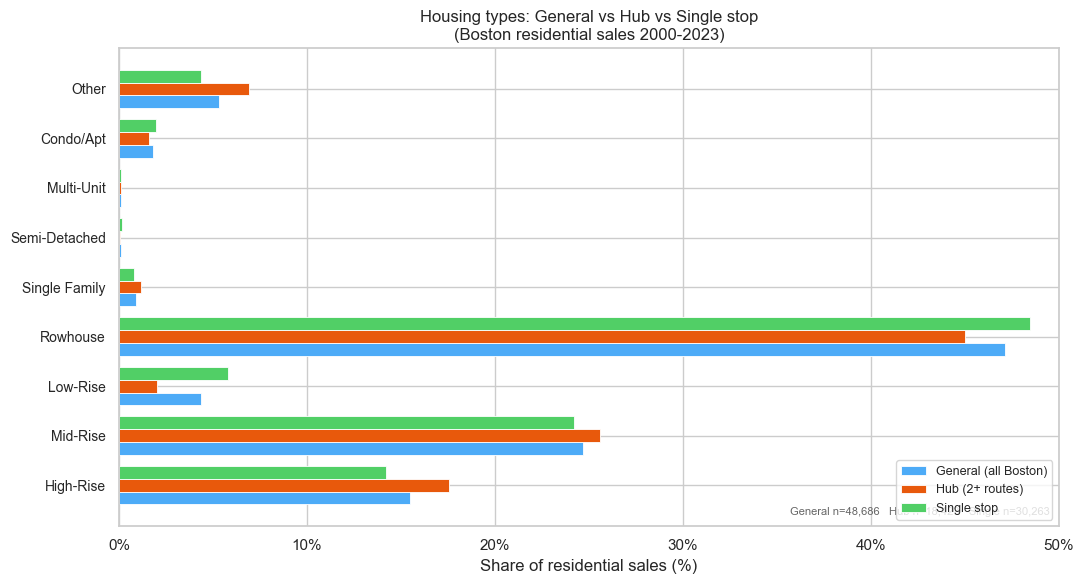

In [99]:
# Q3 Chart: Housing types — General (all Boston), Hub, and Single stop (grouped for direct comparison)
if "sales_clean" not in dir():
    raise RuntimeError("Run the 'Data prep' cell above first.")

STYLES = ["High-Rise", "Mid-Rise", "Low-Rise", "Rowhouse", "Single Family", "Semi-Detached", "Multi-Unit", "Condo/Apt", "Other"]

# Percent of each group in each housing type
general = sales_clean["style_simple"].value_counts(normalize=True).reindex(STYLES, fill_value=0).values * 100
hub = sales_clean[sales_clean["is_hub"]]["style_simple"].value_counts(normalize=True).reindex(STYLES, fill_value=0).values * 100
single = sales_clean[~sales_clean["is_hub"]]["style_simple"].value_counts(normalize=True).reindex(STYLES, fill_value=0).values * 100

n_styles = len(STYLES)
y = np.arange(n_styles)
bar_h = 0.26  # height of each bar segment

fig, ax = plt.subplots(figsize=(11, 6))
# General (all Boston)
b0 = ax.barh(y - bar_h, general, height=bar_h, label="General (all Boston)", color="#4dabf7", edgecolor="white", linewidth=0.6)
# Hub
b1 = ax.barh(y, hub, height=bar_h, label="Hub (2+ routes)", color="#e8590c", edgecolor="white", linewidth=0.6)
# Single stop
b2 = ax.barh(y + bar_h, single, height=bar_h, label="Single stop", color="#51cf66", edgecolor="white", linewidth=0.6)

ax.set_yticks(y)
ax.set_yticklabels(STYLES, fontsize=10)
ax.set_xlabel("Share of residential sales (%)")
ax.set_title("Housing types: General vs Hub vs Single stop\n(Boston residential sales 2000-2023)")
ax.set_xlim(0, 50)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(loc="lower right", frameon=True, fontsize=9)
n_all, n_hub, n_single = len(sales_clean), sales_clean["is_hub"].sum(), (~sales_clean["is_hub"]).sum()
ax.text(0.99, 0.02, f"General n={n_all:,}   Hub n={n_hub:,}   Single n={n_single:,}", transform=ax.transAxes, ha="right", va="bottom", fontsize=8, color="#666")
plt.tight_layout()
plt.savefig("q3-overall-housing-boston.png", dpi=150, bbox_inches="tight")
plt.show()

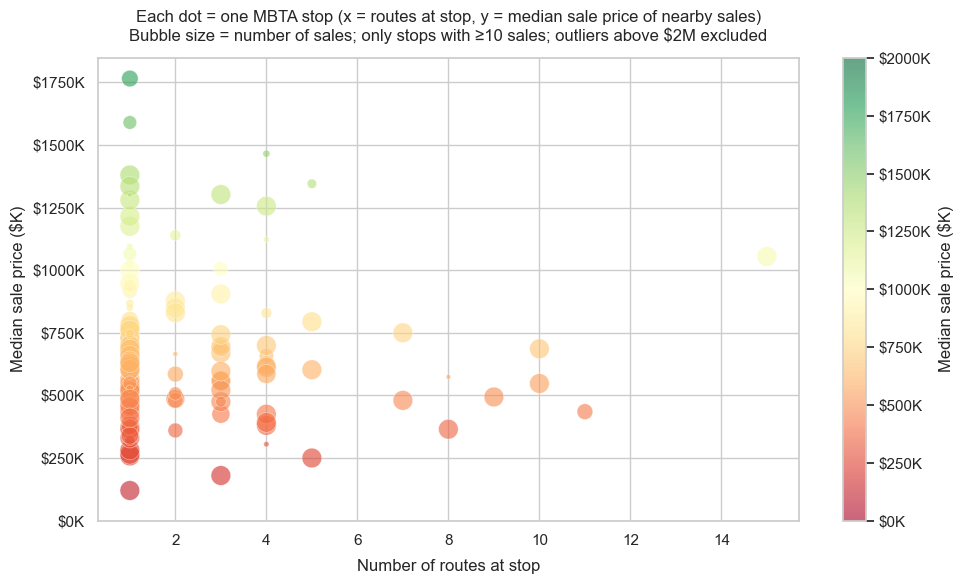

In [100]:
# Q3 Chart 2: One dot per stop — x = number of routes at that stop, y = median sale price (sales nearest that stop)
# Bubble size = number of sales at that stop
if "sales_clean" not in dir():
    raise RuntimeError("Run the 'Data prep' cell above first.")

by_stop = (
    sales_clean
    .groupby("nearest_stop_id")
    .agg(
        median_price=("price", "median"),
        count=("price", "count"),
        n_routes=("n_routes_nearby", "first"),
    )
    .reset_index()
    .query("count >= 10")  # at least 10 sales per stop so median is meaningful
)

# Plot in thousands of dollars ($500K -> 500) and drop extreme outliers so scale is readable
median_k = by_stop["median_price"] / 1e3  # dollars -> $K
cap_k = 2000  # cap at $2M for display; keeps axis in "$0K" to "$2000K"
by_stop = by_stop[median_k <= cap_k].copy()
median_k = by_stop["median_price"] / 1e3

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    by_stop["n_routes"],
    median_k,
    s=by_stop["count"].clip(upper=200),
    alpha=0.6,
    c=median_k,
    cmap="RdYlGn",
    vmin=0,
    vmax=cap_k,
    edgecolors="white",
    linewidth=0.4,
    zorder=3,
)
ax.set_title("Each dot = one MBTA stop (x = routes at stop, y = median sale price of nearby sales)\nBubble size = number of sales; only stops with ≥10 sales; outliers above $2M excluded", fontsize=12, pad=12)
ax.set_xlabel("Number of routes at stop", labelpad=8)
ax.set_ylabel("Median sale price ($K)")
ax.set_ylim(0, None)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
cbar = plt.colorbar(sc, ax=ax, label="Median sale price ($K)")
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
plt.tight_layout()
plt.savefig("q3-routes-vs-price.png", dpi=150, bbox_inches="tight")
plt.show()